# Phân đoạn ảnh màu bằng K-Means, Fuzzy C-Means và KNN (kết hợp bảo toàn biên)

**Đề bài:** Phân đoạn ảnh màu bằng K-Means và Fuzzy C-Means (FCM), đồng thời dùng KNN để phân loại pixel dựa trên mẫu/nhãn đã xác định; kết hợp xử lý bảo toàn biên (edge-preserving processing). Thực hiện với số cụm K=3 đến 5 và so sánh kết quả.

1. **K** = số vùng/số lớp phân đoạn, áp dụng cho cả 3 phương pháp. Tham số riêng của KNN (số láng giềng) giữ cố định ở `N_NEIGHBORS`.
2. **"Mẫu/nhãn đã xác định" cho KNN**: tự động lấy mẫu từ kết quả K-Means (một số pixel đại diện mỗi lớp) làm tập huấn luyện cho KNN, sau đó KNN phân loại lại toàn bộ ảnh.
3. **Bảo toàn biên**: dùng bộ lọc song phương (bilateral filter) một lần trước khi đưa vào cả 3 phương pháp, để so sánh công bằng. Bản đồ biên Canny dùng để **đánh giá**, không dùng để huấn luyện.
4. **Thư viện**: `scikit-learn` cho K-Means và KNN; **Fuzzy C-Means tự cài bằng NumPy**.

In [1]:
import time
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier


IMAGE_PATH = "../../data/images/orange.jpg"
IMG_SIZE = (128, 128)       # (width, height) sau khi resize
K_VALUES = [3, 4, 5]        # so cum / so lop phan doan can so sanh
N_NEIGHBORS = 5             # so lang gieng cua KNN (co dinh, khac voi "K" o tren)
SAMPLES_PER_CLASS = 30      # so pixel mau lay cho moi lop de huan luyen KNN
RANDOM_STATE = 42

def load_image(path, size):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Khong doc duoc anh tai: {path}")
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

img = load_image(IMAGE_PATH, IMG_SIZE)
print("Kich thuoc anh dau vao:", img.shape, img.dtype)


Kich thuoc anh dau vao: (128, 128, 3) uint8


## Bước 1 — Xử lý bảo toàn biên (edge-preserving) & bản đồ biên tham chiếu

So pixel bien (Canny) tren anh da loc: 1239 / 16384


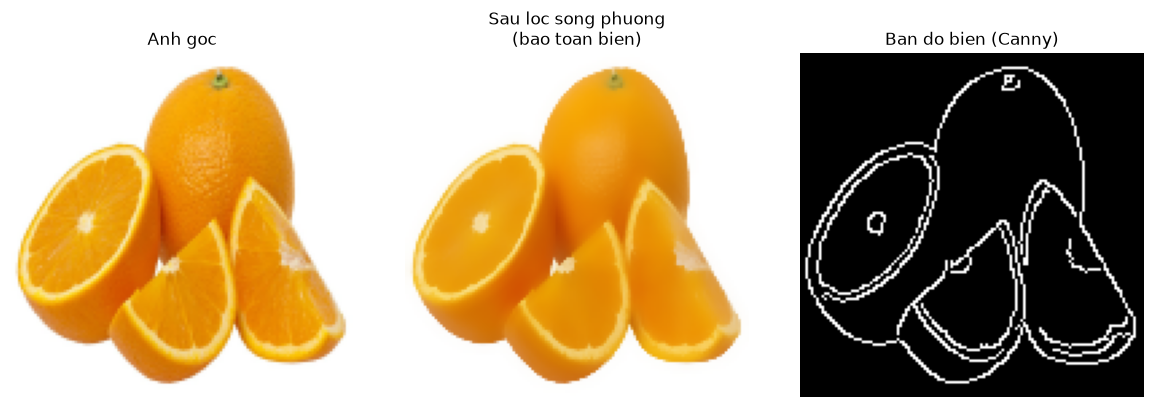

In [2]:
filtered = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
gray = cv2.cvtColor(filtered, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 50, 150)
edge_total = np.count_nonzero(edges)
print(f"So pixel bien (Canny) tren anh da loc: {edge_total} / {edges.size}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img); axes[0].set_title("Anh goc"); axes[0].axis("off")
axes[1].imshow(filtered); axes[1].set_title("Sau loc song phuong\n(bao toan bien)"); axes[1].axis("off")
axes[2].imshow(edges, cmap="gray"); axes[2].set_title("Ban do bien (Canny)"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## Bước 2 — Trích đặc trưng pixel (vector màu RGB, từ ảnh đã lọc)

In [3]:
def build_features(image):
    h, w, c = image.shape
    feats = image.reshape(-1, c).astype(np.float64)
    return feats, (h, w)

features, (H, W) = build_features(filtered)
print("Ma tran dac trung:", features.shape)


Ma tran dac trung: (16384, 3)


## Bước 3 — K-Means (`sklearn.cluster.KMeans`)

In [4]:
def segment_kmeans(feats, k, random_state=RANDOM_STATE):
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
    labels = km.fit_predict(feats)
    dt = time.time() - t0
    return labels, km.cluster_centers_, km.inertia_, dt


## Bước 4 — Fuzzy C-Means (implement bằng NumPy)

Thuật toán FCM chuẩn (Bezdek) với độ mờ `m=2`:
1. Khởi tạo ma trận thành viên `U` ngẫu nhiên (mỗi hàng tổng = 1).
2. Lặp: cập nhật tâm cụm (trung bình có trọng số `U^m`) → cập nhật `U` theo công thức khoảng cách nghịch đảo chuẩn FCM → dừng khi hội tụ hoặc đạt `max_iter`.
3. Nhãn cứng = `argmax` theo hàng của `U`.
4. **Fuzzy Partition Coefficient (FPC)** = trung bình của `U²` — càng gần 1 càng "rõ ràng", càng gần 1/K càng "mờ".

In [5]:
def fuzzy_c_means(feats, c, m=2.0, max_iter=150, tol=1e-5, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n, d = feats.shape
    U = rng.random((n, c))
    U = U / U.sum(axis=1, keepdims=True)

    t0 = time.time()
    n_iter_used = max_iter
    for iteration in range(max_iter):
        um = U ** m
        centers = (um.T @ feats) / um.sum(axis=0)[:, None]
        dist = np.linalg.norm(feats[:, None, :] - centers[None, :, :], axis=2)
        dist = np.fmax(dist, 1e-10)
        power = 2.0 / (m - 1.0)
        ratio = dist[:, :, None] / dist[:, None, :]
        U_new = 1.0 / np.sum(ratio ** power, axis=2)
        delta = np.linalg.norm(U_new - U)
        U = U_new
        if delta < tol:
            n_iter_used = iteration + 1
            break
    dt = time.time() - t0
    hard_labels = np.argmax(U, axis=1)
    fpc = np.sum(U ** 2) / n
    converged = n_iter_used < max_iter
    return hard_labels, U, centers, fpc, dt, n_iter_used, converged


## Bước 5 — KNN phân loại dựa trên mẫu/nhãn đã xác định

`sample_labeled_pixels()` lấy ngẫu nhiên một số pixel đại diện mỗi lớp từ kết quả K-Means làm **"mẫu/nhãn đã xác định"**; `classify_knn()` huấn luyện KNN trên đúng tập mẫu nhỏ này rồi phân loại lại **toàn bộ ảnh**.

In [6]:
def sample_labeled_pixels(feats, cluster_labels, n_per_class, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    sample_feats, sample_labels = [], []
    for lab in np.unique(cluster_labels):
        idx = np.where(cluster_labels == lab)[0]
        chosen = rng.choice(idx, size=min(n_per_class, len(idx)), replace=False)
        sample_feats.append(feats[chosen])
        sample_labels.append(np.full(len(chosen), lab))
    return np.vstack(sample_feats), np.concatenate(sample_labels)


def classify_knn(feats, sample_feats, sample_labels, n_neighbors=N_NEIGHBORS):
    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(sample_feats, sample_labels)
    labels = knn.predict(feats)
    dt = time.time() - t0
    return labels, dt


## Chạy toàn bộ pipeline cho K = 3, 4, 5

In [7]:
def label_boundary_map(label_img):
    gx = np.abs(np.diff(label_img.astype(int), axis=1))
    gy = np.abs(np.diff(label_img.astype(int), axis=0))
    boundary = np.zeros_like(label_img, dtype=np.uint8)
    boundary[:, :-1] |= (gx > 0).astype(np.uint8)
    boundary[:-1, :] |= (gy > 0).astype(np.uint8)
    return boundary


def labels_to_image(label_arr, feats, H, W):
    img_out = np.zeros_like(feats)
    for lab in np.unique(label_arr):
        mask = label_arr == lab
        img_out[mask] = feats[mask].mean(axis=0)
    return img_out.reshape(H, W, -1).astype(np.uint8)


results = {}
metrics_rows = []

for k in K_VALUES:
    km_labels, km_centers, wcss, km_dt = segment_kmeans(features, k)
    fcm_labels, U, fcm_centers, fpc, fcm_dt, fcm_iters, fcm_converged = fuzzy_c_means(features, k)
    sample_feats, sample_labels = sample_labeled_pixels(features, km_labels, SAMPLES_PER_CLASS)
    knn_labels, knn_dt = classify_knn(features, sample_feats, sample_labels)

    results[k] = {
        "kmeans": km_labels.reshape(H, W),
        "fcm": fcm_labels.reshape(H, W),
        "knn": knn_labels.reshape(H, W),
    }

    for method, lab_img, dt_val, extra in [
        ("K-Means", km_labels.reshape(H, W), km_dt, f"WCSS={wcss:.0f}"),
        ("FCM", fcm_labels.reshape(H, W), fcm_dt, f"FPC={fpc:.4f}, iters={fcm_iters}{'(hoi tu)' if fcm_converged else '(cham max_iter)'}"),
        ("KNN", knn_labels.reshape(H, W), knn_dt, f"mau/lop={SAMPLES_PER_CLASS}"),
    ]:
        boundary = label_boundary_map(lab_img)
        overlap = np.logical_and(boundary > 0, edges > 0).sum()
        pct = 100.0 * overlap / max(edge_total, 1)
        metrics_rows.append({
            "K": k, "Phuong phap": method, "Thoi gian (s)": round(dt_val, 4),
            "So pixel bien": int(boundary.sum()),
            "Trung khop Canny (%)": round(pct, 2),
            "Ghi chu": extra,
        })

print("Da chay xong pipeline cho K =", K_VALUES)


Da chay xong pipeline cho K = [3, 4, 5]


## Bước 6 — Trực quan hoá kết quả (K=3,4,5 × 3 phương pháp)

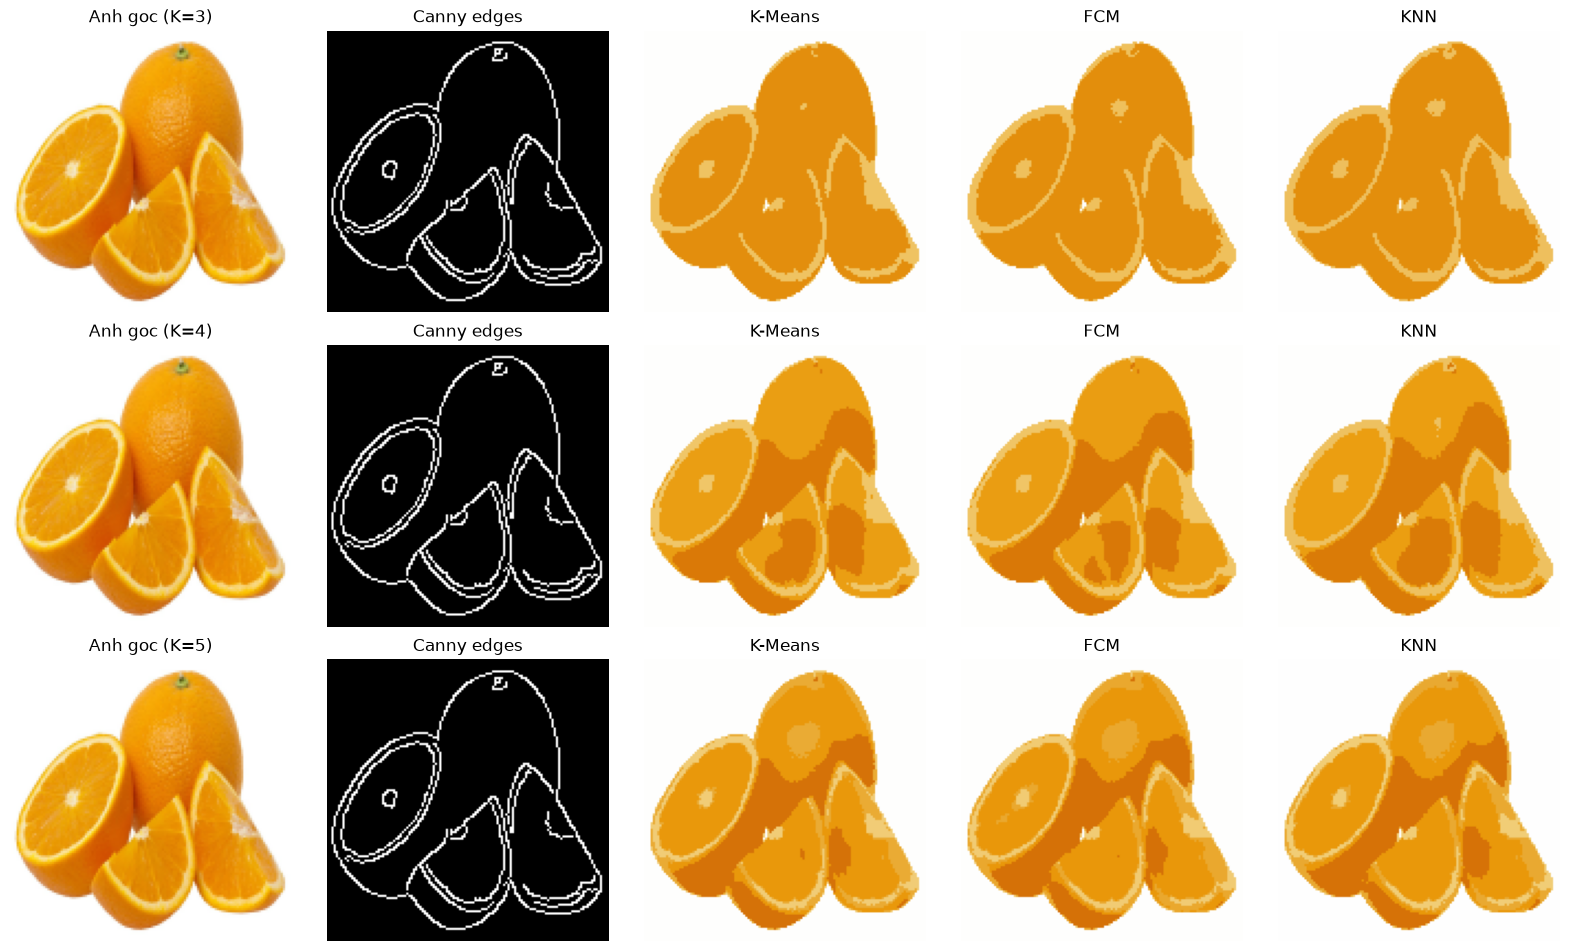

In [8]:
fig, axes = plt.subplots(len(K_VALUES), 5, figsize=(16, 3.2 * len(K_VALUES)))
for i, k in enumerate(K_VALUES):
    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Anh goc (K={k})"); axes[i, 0].axis("off")
    axes[i, 1].imshow(edges, cmap="gray"); axes[i, 1].set_title("Canny edges"); axes[i, 1].axis("off")

    km_img = labels_to_image(results[k]["kmeans"].reshape(-1), features, H, W)
    axes[i, 2].imshow(km_img); axes[i, 2].set_title("K-Means"); axes[i, 2].axis("off")

    fcm_img = labels_to_image(results[k]["fcm"].reshape(-1), features, H, W)
    axes[i, 3].imshow(fcm_img); axes[i, 3].set_title("FCM"); axes[i, 3].axis("off")

    knn_img = labels_to_image(results[k]["knn"].reshape(-1), features, H, W)
    axes[i, 4].imshow(knn_img); axes[i, 4].set_title("KNN"); axes[i, 4].axis("off")

plt.tight_layout()
plt.show()


## Bước 7 — Bảng số liệu so sánh

In [9]:
metrics_df = pd.DataFrame(metrics_rows)
metrics_df


,K,Phuong phap,Thoi gian (s),So pixel bien,Trung khop Canny (%),Ghi chu
0,3,K-Means,0.1254,1318,61.50,WCSS=8241295
1,3,FCM,0.2053,1359,60.94,"FPC=0.9026, iters=43(hoi tu)"
2,3,KNN,0.0151,1399,61.10,mau/lop=30
3,4,K-Means,0.0412,1823,70.46,WCSS=4951317
4,4,FCM,0.3081,1822,70.46,"FPC=0.8454, iters=53(hoi tu)"
5,4,KNN,0.0150,1845,70.38,mau/lop=30
6,5,K-Means,0.0582,2282,77.89,WCSS=3653012
7,5,FCM,1.2253,2328,78.45,"FPC=0.8083, iters=150(cham max_iter)"
8,5,KNN,0.0161,2296,77.97,mau/lop=30


## Nhận xét so sánh (dựa trên bảng số liệu thật đã chạy ở trên)

**Tốc độ chạy**: KNN nhanh nhất trong 3 phương pháp — vì chỉ cần huấn luyện trên
một tập mẫu rất nhỏ (`SAMPLES_PER_CLASS` × K điểm) rồi suy luận, thay vì xử lý
toàn bộ pixel như 2 phương pháp kia. K-Means đứng giữa (nhờ cài đặt tối ưu của
scikit-learn). FCM chậm nhất và **tăng mạnh khi K tăng**, do mỗi vòng lặp phải
tính ma trận khoảng cách đầy đủ giữa mọi pixel và mọi cụm; ở K=5, thuật toán có
thể chạm giới hạn `max_iter=150` mà chưa hội tụ hẳn (xem cột "Ghi chú") — đây là
hạn chế đáng lưu ý của bản cài đặt FCM thuần NumPy so với các thư viện chuyên
dụng đã tối ưu.

**FPC (Fuzzy Partition Coefficient) của FCM**: giảm dần khi K tăng — đúng theo
lý thuyết phân cụm mờ: số cụm càng nhiều, ranh giới giữa các cụm càng "mờ" hơn
(mức độ thuộc về nhiều cụm cùng lúc tăng lên), nên chỉ số phân định rõ ràng
giảm.

**Tỉ lệ trùng khớp với bản đồ biên Canny**: tăng dần theo K ở cả 3 phương pháp
— đây là hệ quả tự nhiên của việc K lớn hơn tạo ra nhiều vùng (và do đó nhiều
biên) hơn, làm tăng cơ hội trùng với bản đồ Canny, **không nên hiểu là "K lớn
bảo toàn biên tốt hơn"**. Chỉ số này có ý nghĩa so sánh hơn khi đặt cạnh nhau
**ở cùng một giá trị K** giữa 3 phương pháp.

**So sánh trực quan giữa 3 phương pháp ở cùng K**: kết quả phân đoạn khá giống
nhau về hình dạng vùng — điều này hợp lý vì KNN được huấn luyện dựa trên chính
nhãn do K-Means tạo ra. FCM có xu hướng cho ranh giới mượt hơn đôi chút nhờ bản
chất phân cụm mờ (mỗi pixel được gán theo mức độ thuộc về nhiều cụm rồi mới lấy
nhãn cứng), trong khi khác biệt rõ rệt nhất giữa 3 phương pháp nằm ở **thời
gian chạy** chứ không phải chất lượng phân đoạn trên ảnh mẫu này.